
# Wind Forecast Analysis - January 2024

This notebook analyses UK wind power forecasts and actual generation using data from the BMRS datasets.

Goals:

1. Analyse forecast errors
2. Understand error distribution and behaviour
3. Analyse reliability of wind power generation
4. Recommend a conservative wind generation capacity that can reliably meet electricity demand



## 1. Install Dependencies
Run this only if required.


In [ ]:

# !pip install pandas requests matplotlib seaborn



## 2. Import Libraries


In [20]:

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")



## 3. Fetch Data from BMRS APIs
Actual generation comes from the FUELHH dataset (fuelType=WIND).
Forecast data comes from the WINDFOR dataset.


In [21]:
BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1/datasets"
MAX_WINDOW_DAYS = 7


def fetch_stream(endpoint, params):
    """Fetch data from a BMRS stream endpoint, honoring the 7-day window limit."""
    from datetime import datetime, timedelta

    start = datetime.fromisoformat(params["publishDateTimeFrom"].replace("Z", "+00:00"))
    end = datetime.fromisoformat(params["publishDateTimeTo"].replace("Z", "+00:00"))

    results = []
    window_start = start
    while window_start < end:
        window_end = min(window_start + timedelta(days=MAX_WINDOW_DAYS), end)

        p = {
            **params,
            "publishDateTimeFrom": window_start.isoformat().replace("+00:00", "Z"),
            "publishDateTimeTo": window_end.isoformat().replace("+00:00", "Z"),
        }

        r = requests.get(f"{BASE_URL}/{endpoint}", params=p)
        r.raise_for_status()

        batch = r.json()
        if isinstance(batch, dict) and "data" in batch:
            batch = batch["data"]

        results.extend(batch)
        window_start = window_end

    return results


def fetch_actual():
    params = {
        "publishDateTimeFrom": "2024-01-01T00:00:00Z",
        "publishDateTimeTo": "2024-01-31T23:30:00Z",
        "fuelType": "WIND",
        "format": "json",
    }

    data = fetch_stream("FUELHH/stream", params)

    df = pd.DataFrame(data)
    df = df[df["fuelType"].str.upper() == "WIND"]
    df = df[["startTime", "generation"]].rename(columns={"generation": "actual"})

    return df


def fetch_forecast():
    params = {
        # We fetch a little earlier to support 0-48h horizon for early January targets.
        "publishDateTimeFrom": "2023-12-30T00:00:00Z",
        "publishDateTimeTo": "2024-01-31T23:30:00Z",
        "format": "json",
    }

    data = fetch_stream("WINDFOR/stream", params)

    df = pd.DataFrame(data)
    df = df[["startTime", "publishTime", "generation"]].rename(columns={"generation": "forecast"})

    return df


def select_latest_forecasts(forecast_df, horizon_hours=4):
    # For each target time, select the latest forecast that was published at least `horizon_hours`
    # before the target time.
    forecast_df = forecast_df.copy()
    forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
    forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

    cutoff = forecast_df["startTime"] - pd.Timedelta(hours=horizon_hours)
    eligible = forecast_df[forecast_df["publishTime"] <= cutoff]

    idx = eligible.groupby("startTime")["publishTime"].idxmax()
    return eligible.loc[idx].drop(columns=["startTime"]).assign(startTime=eligible.loc[idx, "startTime"])


actual_df = fetch_actual()
forecast_df = fetch_forecast()

# Use 4-hour horizon by default (same default as the demo app)
forecast_horizon_hours = 4
latest_forecast = select_latest_forecasts(forecast_df, horizon_hours=forecast_horizon_hours)

print("Actual rows:", len(actual_df))
print("Forecast rows:", len(forecast_df))
print(f"Selected forecasts (horizon={forecast_horizon_hours}h):", len(latest_forecast))

actual_df.head()


Actual rows: 1492
Forecast rows: 12936
Selected forecasts (horizon=4h): 817


,startTime,actual
0,2024-01-07T23:30:00Z,4275
1,2024-01-07T23:00:00Z,4242
2,2024-01-07T22:30:00Z,4100
3,2024-01-07T22:00:00Z,3994
4,2024-01-07T21:30:00Z,4030



## 4. Data Preparation
Convert timestamps to datetime format and select the latest forecast for each target time.


In [22]:

actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])

forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

latest_forecast = (
    forecast_df
    .sort_values("publishTime")
    .groupby("startTime")
    .tail(1)
)

merged = pd.merge(
    actual_df,
    latest_forecast[["startTime", "forecast"]],
    on="startTime"
)

merged.head()


,startTime,actual,forecast
0,2024-01-07 23:00:00+00:00,4242,4245
1,2024-01-07 22:00:00+00:00,3994,4098
2,2024-01-07 21:00:00+00:00,3992,4162
3,2024-01-07 20:00:00+00:00,4032,4591
4,2024-01-07 19:00:00+00:00,4202,4545



## 5. Compute Forecast Error


In [23]:

merged["error"] = merged["forecast"] - merged["actual"]
merged["abs_error"] = merged["error"].abs()

merged.head()


,startTime,actual,forecast,error,abs_error
0,2024-01-07 23:00:00+00:00,4242,4245,3,3
1,2024-01-07 22:00:00+00:00,3994,4098,104,104
2,2024-01-07 21:00:00+00:00,3992,4162,170,170
3,2024-01-07 20:00:00+00:00,4032,4591,559,559
4,2024-01-07 19:00:00+00:00,4202,4545,343,343


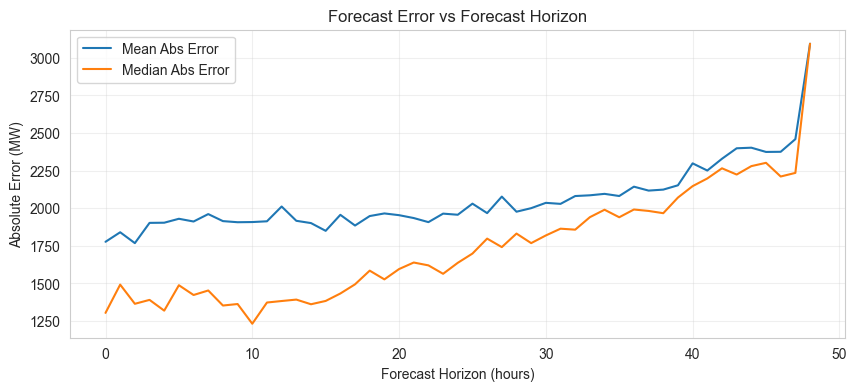

In [24]:
# 5b. Error vs. Forecast Horizon (0–48h)
# We compute the age of each forecast (startTime - publishTime) and then look at error
# characteristics by the forecast horizon.

# Ensure the merge keys are datetime
actual_df["startTime"] = pd.to_datetime(actual_df["startTime"])
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"])
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"])

forecast_df["horizon_hours"] = (forecast_df["startTime"] - forecast_df["publishTime"]).dt.total_seconds() / 3600.0
forecast_df = forecast_df[(forecast_df["horizon_hours"] >= 0) & (forecast_df["horizon_hours"] <= 48)]

horizon_merge = pd.merge(
    actual_df,
    forecast_df[["startTime", "horizon_hours", "forecast"]],
    on="startTime",
    how="inner"
)

horizon_merge["error"] = horizon_merge["forecast"] - horizon_merge["actual"]
horizon_merge["abs_error"] = horizon_merge["error"].abs()

# Bin horizons to integer hours for a clearer view
horizon_merge["horizon_bin"] = horizon_merge["horizon_hours"].astype(int)

horizon_stats = (
    horizon_merge
    .groupby("horizon_bin")["abs_error"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

plt.figure(figsize=(10,4))
plt.plot(horizon_stats["horizon_bin"], horizon_stats["mean"], label="Mean Abs Error")
plt.plot(horizon_stats["horizon_bin"], horizon_stats["median"], label="Median Abs Error")
plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Absolute Error (MW)")
plt.title("Forecast Error vs Forecast Horizon")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 6. Forecast Error Statistics


In [25]:

stats = merged["abs_error"].describe(percentiles=[0.5, 0.9, 0.99])
stats


count      744.000000
mean      1820.564516
std       1604.156574
min          3.000000
50%       1434.500000
90%       3969.600000
99%       6282.340000
max      17983.000000
Name: abs_error, dtype: float64


### Interpretation

Mean and median values represent typical forecast errors, while the 99th percentile shows worst-case forecast deviation.



## 7. Forecast Error Distribution


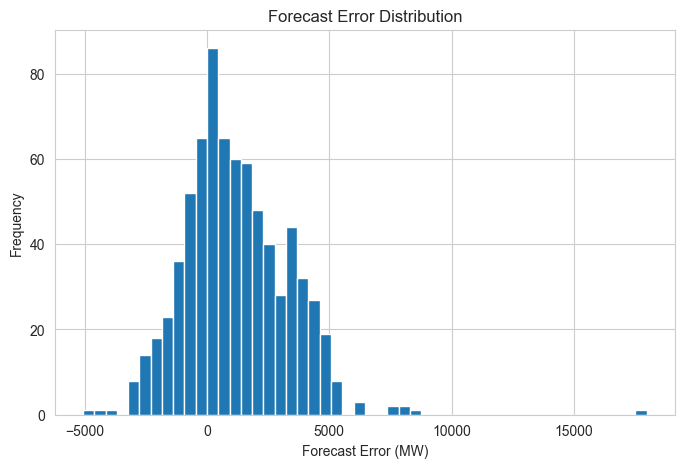

In [26]:

plt.figure(figsize=(8,5))

plt.hist(merged["error"], bins=50)

plt.title("Forecast Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")

plt.show()



## 8. Error by Time of Day
Wind forecasts may behave differently depending on the time of day.


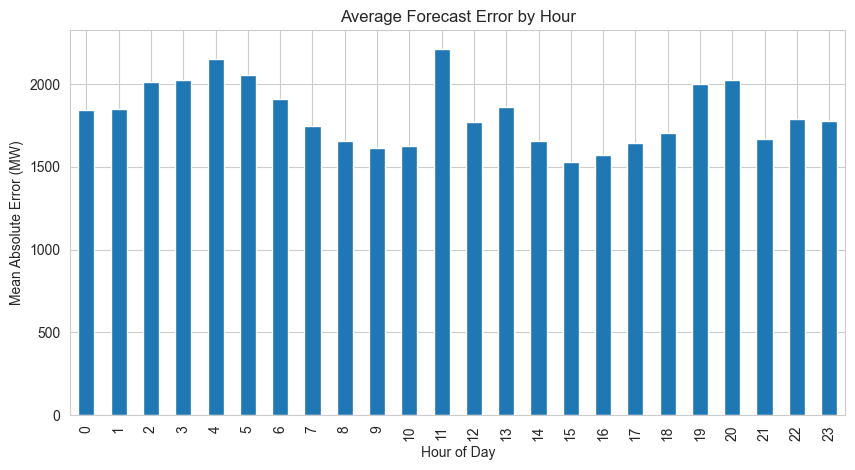

In [27]:

merged["hour"] = merged["startTime"].dt.hour

hourly_error = merged.groupby("hour")["abs_error"].mean()

plt.figure(figsize=(10,5))

hourly_error.plot(kind="bar")

plt.title("Average Forecast Error by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Absolute Error (MW)")

plt.show()



## 9. Wind Generation Distribution
Analyse how actual wind generation varies across the dataset.


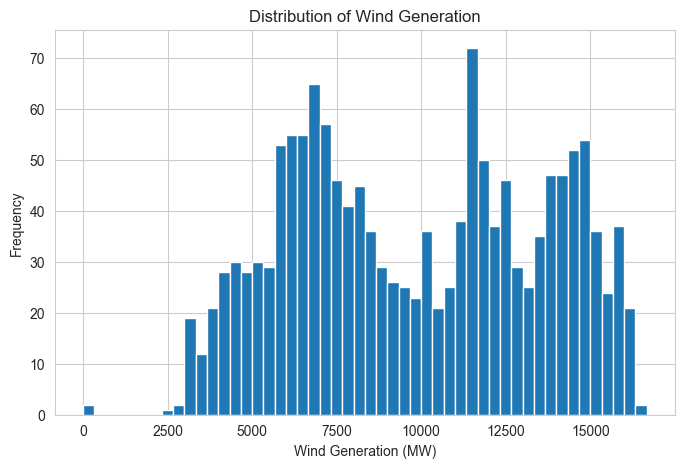

In [28]:

plt.figure(figsize=(8,5))

plt.hist(actual_df["actual"], bins=50)

plt.title("Distribution of Wind Generation")
plt.xlabel("Wind Generation (MW)")
plt.ylabel("Frequency")

plt.show()



## 10. Wind Reliability Analysis

We estimate how much wind power can reliably meet electricity demand.

Using percentiles:

- 10th percentile → conservative estimate
- 50th percentile → typical generation


In [29]:

actual_stats = actual_df["actual"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9])
p10 = actual_stats["10%"]
p50 = actual_stats["50%"]

p90 = actual_stats["90%"]

print(f"90th percentile generation: {p90:,.0f} MW")
print(f"10th percentile generation: {p10:,.0f} MW")
print(f"Median generation: {p50:,.0f} MW")

90th percentile generation: 14,808 MW
10th percentile generation: 5,084 MW
Median generation: 9,864 MW



## 11. Recommendation

In January 2024, the **10th percentile** of wind generation is **≈ 5.1 GW (≈ 5,084 MW)**.
This means wind generation was at or above this level **90% of the time** in the dataset.

### Suggested reliable capacity

- **Conservative baseline (90% reliability)**: **≈ 5.1 GW**
- For stronger reliability (95%+), plan smaller (e.g., **4.5–5.0 GW**) to account for deeper low-wind periods.

Wind is highly variable, so relying on average or peak values will overstate the dependable contribution. Using percentile-based planning better matches the reliability needs of an electricity system.



## 12. Conclusion

Key findings:

- Wind forecasts have noticeable error, especially during periods of rapidly changing wind conditions.
- Forecast error varies throughout the day.
- Wind generation is highly variable but still provides a significant contribution to electricity supply.

Using percentile-based analysis allows energy planners to estimate a **reliable wind generation capacity** that can support electricity demand planning.
